    Fast  Slow  Final Equity    Sharpe
0      3     9      1.208037  0.203100
10     4     9      1.146573  0.153035
1      3    10      1.143689  0.150846
11     4    10      1.122289  0.132164
3      3    12      1.111498  0.123815
4      3    13      1.106180  0.115692
6      3    15      1.097919  0.113788
2      3    11      1.101484  0.113138
7      3    16      1.088049  0.105536
20     5     9      1.099998  0.105254


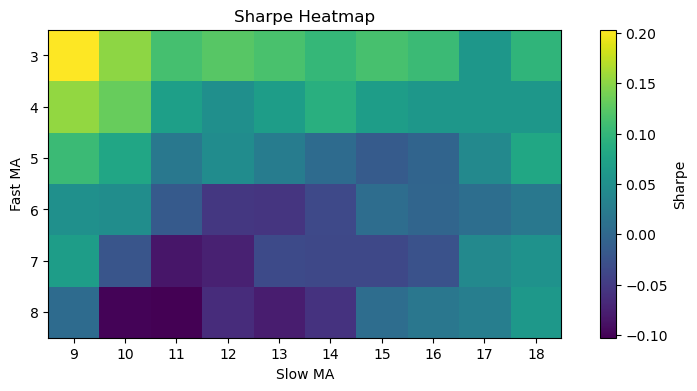

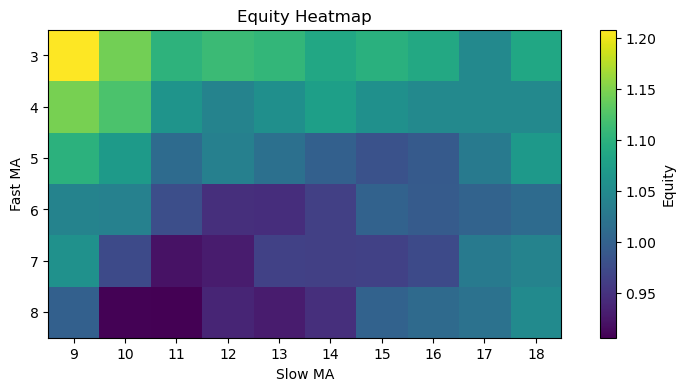

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = [100, 102, 101, 103, 105, 104, 106, 108, 107, 109,
111, 110, 108, 106, 104, 103, 101, 100, 98, 99,
101, 103, 102, 104, 106, 108, 110, 109, 111, 113,
112, 110, 108, 107, 105, 103, 104, 106, 108, 107,
109, 111, 113, 115, 114, 116, 118, 117, 115, 113,
112, 110, 108, 109, 111, 113, 112, 114, 116, 118,
117, 119, 121, 120, 122, 124, 123, 121, 119, 120,
122, 124, 126, 125, 127, 129, 128, 130, 132, 131]

base_df = pd.DataFrame({'Prices': data})
base_df['Return'] = base_df['Prices'].pct_change()

fast_range = range(3,9)
slow_range = range(9,19)

results = []

for fast in fast_range :
    for slow in slow_range:
        if fast >= slow :
            continue
        
        df = base_df.copy()
        df['Fast_MA'] = df['Prices'].rolling(window=fast).mean()
        df['Slow_MA'] = df['Prices'].rolling(window=slow).mean()
        df['Signal'] = np.where(df['Fast_MA'] > df['Slow_MA'],1,0)
        df['Strategy_Return'] = df['Return'] * df['Signal'].shift(1)
        df['Strategy_Return'] = df['Strategy_Return'].fillna(0)
        df['Equity_Curve'] = (1 + df['Strategy_Return']).cumprod()
        final_equity = df['Equity_Curve'].iloc[-1]
        sharpe = df['Strategy_Return'].mean() / df['Strategy_Return'].std()
        results.append([fast,slow,final_equity,sharpe])
        


result_df = pd.DataFrame(results,columns=['Fast','Slow','Final Equity','Sharpe'])
top_10_params = result_df.sort_values(by='Sharpe',ascending=False ).head(10)
print(top_10_params)


sharpe_heatmap = result_df.pivot(index = 'Fast',columns = 'Slow',values = 'Sharpe')
equity_heatmap = result_df.pivot(index= 'Fast',columns='Slow',values = 'Final Equity')

plt.figure(figsize = (10,4))
plt.imshow(sharpe_heatmap)

plt.xticks(range(len(sharpe_heatmap.columns)) , sharpe_heatmap.columns)
plt.yticks(range(len(sharpe_heatmap.index)) , sharpe_heatmap.index )

plt.xlabel('Slow MA')
plt.ylabel('Fast MA')
plt.title('Sharpe Heatmap')

plt.colorbar(label = 'Sharpe')
plt.show()

plt.figure(figsize=(10,4))
plt.imshow(equity_heatmap)

plt.xticks(range(len(equity_heatmap.columns)),equity_heatmap.columns )
plt.yticks(range(len(equity_heatmap.index)),equity_heatmap.index)

plt.xlabel('Slow MA')
plt.ylabel('Fast MA')
plt.title('Equity Heatmap')

plt.colorbar(label = 'Equity')
plt.show()



## Observations

1. The top 10 parameter combinations were checked to identify which Fast MA and Slow MA values produced the highest Sharpe.
2. The Sharpe heatmap shows how risk-adjusted performance changes across different parameter combinations.
3. The final equity heatmap shows how total compounded performance changes across parameter combinations.
4. If strong values appear across nearby Fast/Slow MA combinations, the strategy looks more robust.
5. If only one isolated parameter combination performs well, the strategy may be overfit.
6. Since the dataset is small, the heatmap is useful for learning robustness analysis but not enough to trust the strategy in real markets.
